# Text-to-Image and Image-to-image search Using CLIP

## Import libraries

In [ ]:
#! pip install urllib3 -U
# !pip install --upgrade --force-reinstall datasets

In [1]:
import torch
import requests
import pandas as pd
from PIL import Image
from io import BytesIO
from datasets import load_dataset
from transformers import CLIPProcessor, CLIPModel, CLIPTokenizer

## Image Exploration

### Load Data

In [2]:
# https://huggingface.co/datasets/conceptual_captions
image_data = load_dataset(
    "conceptual_captions", split="train",
    )

README.md:   0%|          | 0.00/14.2k [00:00<?, ?B/s]

train-00000-of-00002.parquet:   0%|          | 0.00/187M [00:00<?, ?B/s]

train-00001-of-00002.parquet:   0%|          | 0.00/187M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/1.77M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3318333 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/15840 [00:00<?, ? examples/s]

In [3]:
image_data

Dataset({
    features: ['image_url', 'caption'],
    num_rows: 3318333
})

We will select a sample of 300 images from this large number of images (3 318 333)

Let's examine how the dataset is structured

In [4]:
image_data_df = pd.DataFrame(image_data[:30])

In [8]:
image_data_df

,image_url,caption
0,http://lh6.ggpht.com/-IvRtNLNcG8o/TpFyrudaT6I/...,a very typical bus station
1,http://78.media.tumblr.com/3b133294bdc7c7784b7...,sierra looked stunning in this top and this sk...
2,https://media.gettyimages.com/photos/young-con...,young confused girl standing in front of a war...
3,https://thumb1.shutterstock.com/display_pic_wi...,interior design of modern living room with fir...
4,https://thumb1.shutterstock.com/display_pic_wi...,cybernetic scene isolated on white background .
5,https://media.gettyimages.com/photos/jayz-atte...,gangsta rap artist attends sports team vs play...
6,https://prismpub.com/wp-content/uploads/2016/1...,the jetty : different types of plants to estab...
7,https://thumb1.shutterstock.com/display_pic_wi...,traditional ornamental floral paisley bandanna .
8,https://media.gettyimages.com/photos/bryan-mcc...,# of the sports team skates against sports tea...
9,http://www.robinhoodshow.com/clients/17668/864...,by geographical feature category or in the cit...


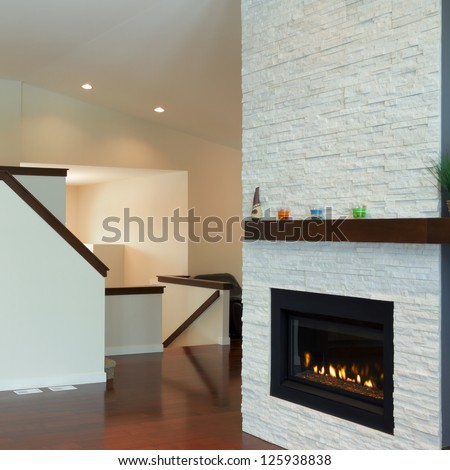

In [9]:
img_url = image_data_df.iloc[3]["image_url"]
image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')
image

In [6]:
image_data_df.iloc[3]["caption"]

'interior design of modern living room with fireplace in a new house'

In [10]:
"""
Not all the URLs are valid. This function returns True if the URL is valid. False otherwise. 
"""
def check_valid_URLs(image_URL):

    try:
      response = requests.get(image_URL)
      Image.open(BytesIO(response.content))
      return True
    except:
      return False

def get_image(image_URL):

    response = requests.get(image_URL)
    image = Image.open(BytesIO(response.content)).convert("RGB")

    return image

def get_image_caption(image_ID):

    return image_data[image_ID]["caption"]

In [11]:
# Transform dataframe
image_data_df["is_valid"] = image_data_df["image_url"].apply(check_valid_URLs)

In [12]:
image_data_df = image_data_df[image_data_df["is_valid"]==True]
image_data_df.head()

,image_url,caption,is_valid
0,http://lh6.ggpht.com/-IvRtNLNcG8o/TpFyrudaT6I/...,a very typical bus station,True
1,http://78.media.tumblr.com/3b133294bdc7c7784b7...,sierra looked stunning in this top and this sk...,True
3,https://thumb1.shutterstock.com/display_pic_wi...,interior design of modern living room with fir...,True
4,https://thumb1.shutterstock.com/display_pic_wi...,cybernetic scene isolated on white background .,True
6,https://prismpub.com/wp-content/uploads/2016/1...,the jetty : different types of plants to estab...,True


In [13]:
image_data_df.shape

(18, 3)

In [14]:
image_data_df["image"] = image_data_df["image_url"].apply(get_image)

/Users/cfenollosa/Documents/Charlas y docencia/20240800 Ironhack AI/2 Classes/FT/Code/venv/lib/python3.9/site-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/var/folders/p8/n90ktjvn0mz196zbqfk664tm0000gn/T/ipykernel_67203/3068950788.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  image_data_df["image"] = image_data_df["image_url"].apply(get_image)


all shots by by person and rider shots can be found on his website .


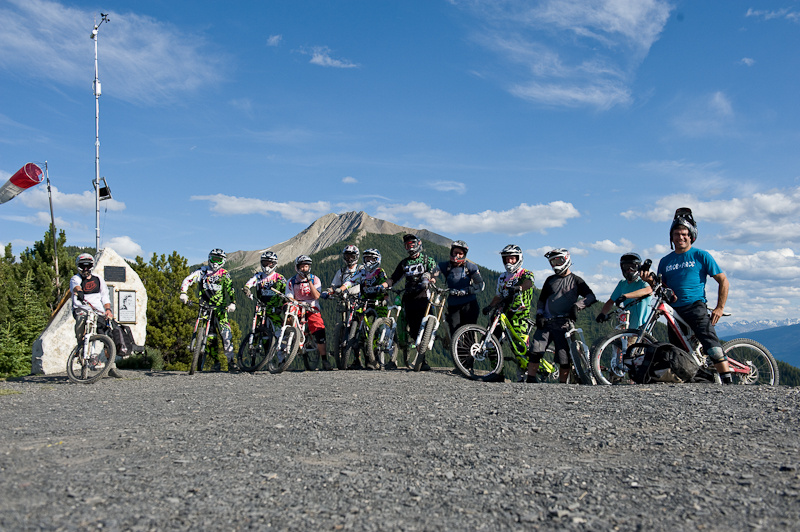

In [16]:
print(image_data_df.iloc[10]["caption"])
image_data_df.iloc[10]["image"]

## Load the model

In [18]:
def get_model_info(model_ID, device):

  # Save the model to device
  model = CLIPModel.from_pretrained(model_ID).to(device)

  # Get the processor
  processor = CLIPProcessor.from_pretrained(model_ID)

  # Get the tokenizer
  tokenizer = CLIPTokenizer.from_pretrained(model_ID)

  # Return model, processor & tokenizer
  return model, processor, tokenizer

In [19]:
# Set the device
device = "cuda" if torch.cuda.is_available() else "cpu"

model_ID = "openai/clip-vit-base-patch32"

model, processor, tokenizer = get_model_info(model_ID, device)

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

/Users/cfenollosa/Documents/Charlas y docencia/20240800 Ironhack AI/2 Classes/FT/Code/venv/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


## Create Embeddings: Text and Image Embeddings

### Text Embeddings

In [20]:
def get_single_text_embedding(text):

  inputs = tokenizer(text, return_tensors = "pt").to(device)

  text_embeddings = model.get_text_features(**inputs)

  # convert the embeddings to numpy array 
  embedding_as_np = text_embeddings.cpu().detach().numpy()

  return embedding_as_np

In [21]:
def get_all_text_embeddings(df, text_col):

   df["text_embeddings"] = df[str(text_col)].apply(get_single_text_embedding)

   return df 

In [22]:
image_data_df = get_all_text_embeddings(image_data_df, "caption")

/var/folders/p8/n90ktjvn0mz196zbqfk664tm0000gn/T/ipykernel_67203/2982579764.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["text_embeddings"] = df[str(text_col)].apply(get_single_text_embedding)


In [23]:
image_data_df.head()

,image_url,caption,is_valid,image,text_embeddings
0,http://lh6.ggpht.com/-IvRtNLNcG8o/TpFyrudaT6I/...,a very typical bus station,True,<PIL.Image.Image image mode=RGB size=800x534 a...,"[[0.2592226, -0.08825933, 0.020317184, -0.1270..."
1,http://78.media.tumblr.com/3b133294bdc7c7784b7...,sierra looked stunning in this top and this sk...,True,<PIL.Image.Image image mode=RGB size=500x441 a...,"[[0.004146969, 0.18943559, -0.12397004, 0.3029..."
3,https://thumb1.shutterstock.com/display_pic_wi...,interior design of modern living room with fir...,True,<PIL.Image.Image image mode=RGB size=450x470 a...,"[[0.5606449, -0.15138124, -0.43740305, -0.3392..."
4,https://thumb1.shutterstock.com/display_pic_wi...,cybernetic scene isolated on white background .,True,<PIL.Image.Image image mode=RGB size=450x470 a...,"[[0.035292387, 0.24262668, -0.12724856, -0.210..."
6,https://prismpub.com/wp-content/uploads/2016/1...,the jetty : different types of plants to estab...,True,<PIL.Image.Image image mode=RGB size=1200x678 ...,"[[0.18494713, 0.37737152, 0.23176083, -0.14631..."


### Image Embeddings

In [24]:
def get_single_image_embedding(my_image):

  image = processor(
      text = None,
      images = my_image, 
      return_tensors="pt"
  )["pixel_values"].to(device)

  embedding = model.get_image_features(image)

  # convert the embeddings to numpy array
  embedding_as_np = embedding.cpu().detach().numpy()

  return embedding_as_np

### Get the embedding of all the images

In [25]:
def get_all_images_embedding(df, img_column):

  df["img_embeddings"] = df[str(img_column)].apply(get_single_image_embedding)

  return df

In [26]:
image_data_df = get_all_images_embedding(image_data_df, "image")

/var/folders/p8/n90ktjvn0mz196zbqfk664tm0000gn/T/ipykernel_67203/763641576.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["img_embeddings"] = df[str(img_column)].apply(get_single_image_embedding)


In [27]:
image_data_df.head()

,image_url,caption,is_valid,image,text_embeddings,img_embeddings
0,http://lh6.ggpht.com/-IvRtNLNcG8o/TpFyrudaT6I/...,a very typical bus station,True,<PIL.Image.Image image mode=RGB size=800x534 a...,"[[0.2592226, -0.08825933, 0.020317184, -0.1270...","[[-0.0034008948, -0.053584103, 0.35247526, 0.3..."
1,http://78.media.tumblr.com/3b133294bdc7c7784b7...,sierra looked stunning in this top and this sk...,True,<PIL.Image.Image image mode=RGB size=500x441 a...,"[[0.004146969, 0.18943559, -0.12397004, 0.3029...","[[-0.25020352, -0.13257758, 0.097062305, 0.978..."
3,https://thumb1.shutterstock.com/display_pic_wi...,interior design of modern living room with fir...,True,<PIL.Image.Image image mode=RGB size=450x470 a...,"[[0.5606449, -0.15138124, -0.43740305, -0.3392...","[[-0.16011202, -0.29582912, -0.11380411, -0.04..."
4,https://thumb1.shutterstock.com/display_pic_wi...,cybernetic scene isolated on white background .,True,<PIL.Image.Image image mode=RGB size=450x470 a...,"[[0.035292387, 0.24262668, -0.12724856, -0.210...","[[0.18214546, 0.050186355, -0.6418867, -0.0791..."
6,https://prismpub.com/wp-content/uploads/2016/1...,the jetty : different types of plants to estab...,True,<PIL.Image.Image image mode=RGB size=1200x678 ...,"[[0.18494713, 0.37737152, 0.23176083, -0.14631...","[[0.054597594, -0.13548774, -0.0031630143, -0...."


### Helper function to plot images

In [28]:
import matplotlib.pyplot as plt

def plot_images(images):

  for image in images:
    plt.imshow(image)
    plt.show()

def plot_images_by_side(top_images):

  index_values = list(top_images.index.values)
  list_images = [top_images.iloc[idx].image for idx in index_values] 
  list_captions = [top_images.iloc[idx].caption for idx in index_values] 
  similarity_score = [top_images.iloc[idx].cos_sim for idx in index_values] 

  n_row = n_col = 2

  _, axs = plt.subplots(n_row, n_col, figsize=(12, 12))
  axs = axs.flatten()
  for img, ax, caption, sim_score in zip(list_images, axs, list_captions, similarity_score):
      ax.imshow(img)
      sim_score = 100*float("{:.2f}".format(sim_score))
      ax.title.set_text(f"Caption: {caption}\nSimilarity: {sim_score}%")
  plt.show()

## Perform Similarity Search: Cosine 

### 1. Cosine Similarity Search

In [29]:
from sklearn.metrics.pairwise import cosine_similarity

In [30]:
def get_top_N_images(query, data, top_K=4, search_criterion="text"):

    """
    Retrieve top_K (5 is default value) articles similar to the query
    """
    # Text to image Search
    if(search_criterion.lower() == "text"):
      query_vect = get_single_text_embedding(query)

    # Image to image Search
    else: 
      query_vect = get_single_image_embedding(query)

    # Relevant columns
    revevant_cols = ["caption", "image", "cos_sim"]
    
    # Run similarity Search
    data["cos_sim"] = data["img_embeddings"].apply(lambda x: cosine_similarity(query_vect, x))

    data["cos_sim"] = data["cos_sim"].apply(lambda x: x[0][0])
    
    """
    Sort Cosine Similarity Column in Descending Order 
    Here we start at 1 to remove similarity with itself because it is always 1
    """
    most_similar_articles = data.sort_values(by='cos_sim', ascending=False)[1:top_K+1]
    
    return most_similar_articles[revevant_cols].reset_index()

In [31]:
image_data_df.columns

Index(['image_url', 'caption', 'is_valid', 'image', 'text_embeddings',
       'img_embeddings'],
      dtype='object')

#### a. Text to image search

In [32]:
query_caption = image_data_df.iloc[10].caption

top_images = get_top_N_images(query_caption, image_data_df)
print("Query: {}".format(query_caption))
top_images

Query: all shots by by person and rider shots can be found on his website .


/var/folders/p8/n90ktjvn0mz196zbqfk664tm0000gn/T/ipykernel_67203/1340004949.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["cos_sim"] = data["img_embeddings"].apply(lambda x: cosine_similarity(query_vect, x))
/var/folders/p8/n90ktjvn0mz196zbqfk664tm0000gn/T/ipykernel_67203/1340004949.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["cos_sim"] = data["cos_sim"].apply(lambda x: x[0][0])


,index,caption,image,cos_sim
0,7,traditional ornamental floral paisley bandanna .,<PIL.Image.Image image mode=RGB size=450x470 a...,0.218309
1,3,interior design of modern living room with fir...,<PIL.Image.Image image mode=RGB size=450x470 a...,0.214863
2,27,young business woman on a bench,<PIL.Image.Image image mode=RGB size=640x447 a...,0.210659
3,4,cybernetic scene isolated on white background .,<PIL.Image.Image image mode=RGB size=450x470 a...,0.204554


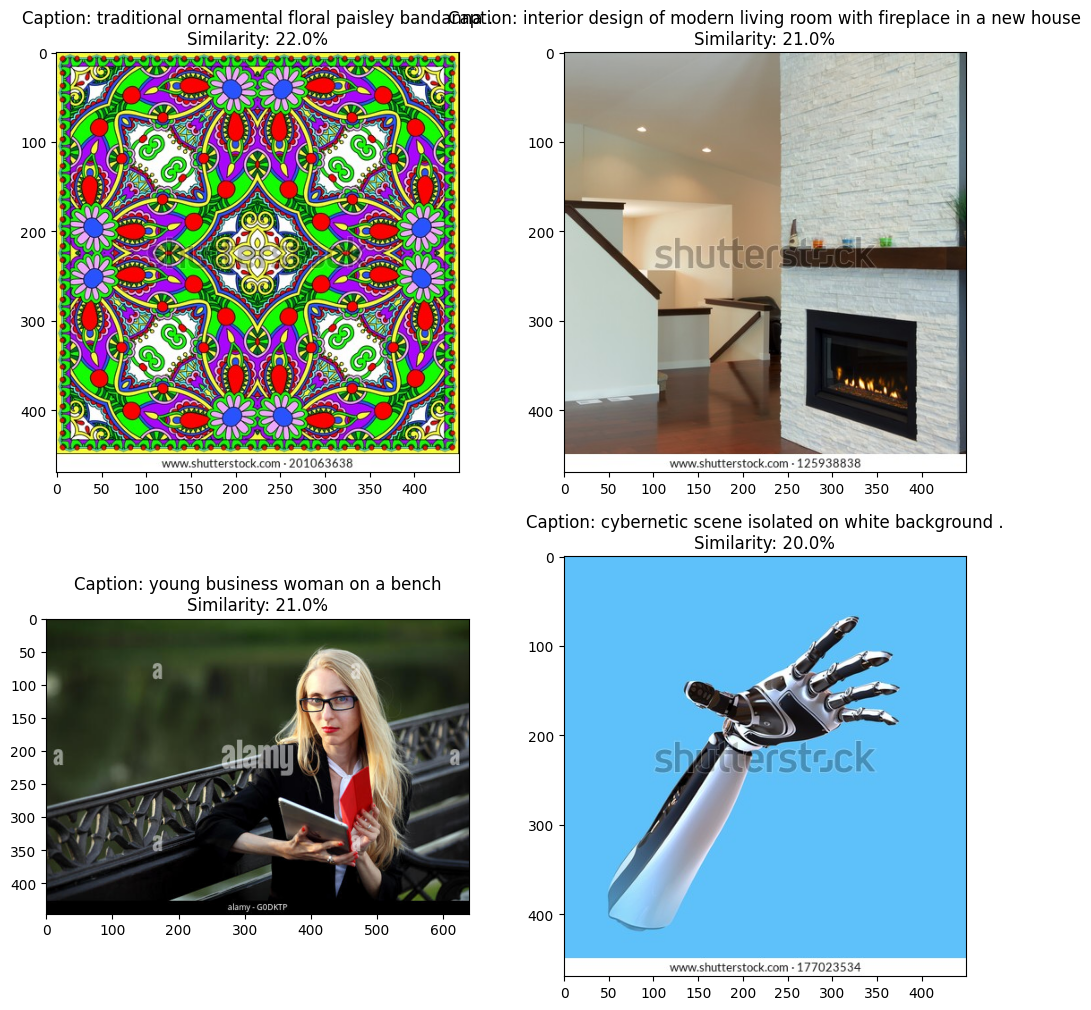

In [33]:
plot_images_by_side(top_images)

#### b. Image to image search

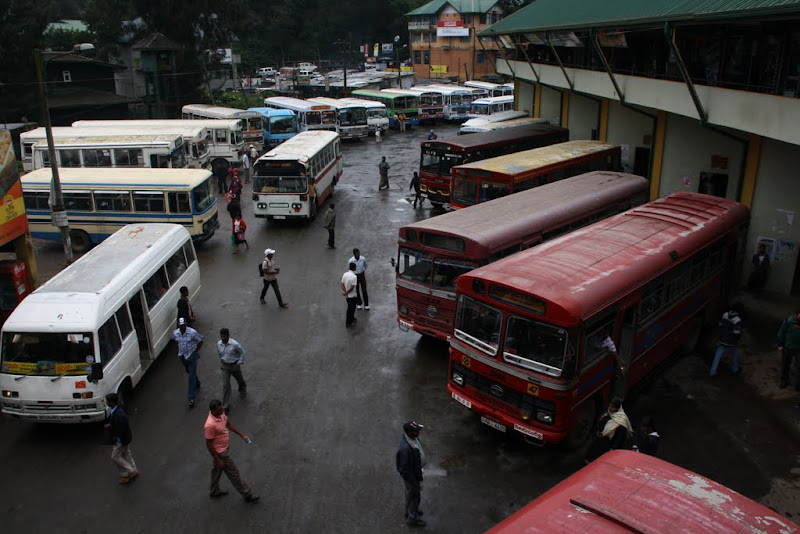

In [35]:
query_image = image_data_df.iloc[0].image
query_image

/var/folders/p8/n90ktjvn0mz196zbqfk664tm0000gn/T/ipykernel_67203/1340004949.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["cos_sim"] = data["img_embeddings"].apply(lambda x: cosine_similarity(query_vect, x))
/var/folders/p8/n90ktjvn0mz196zbqfk664tm0000gn/T/ipykernel_67203/1340004949.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["cos_sim"] = data["cos_sim"].apply(lambda x: x[0][0])


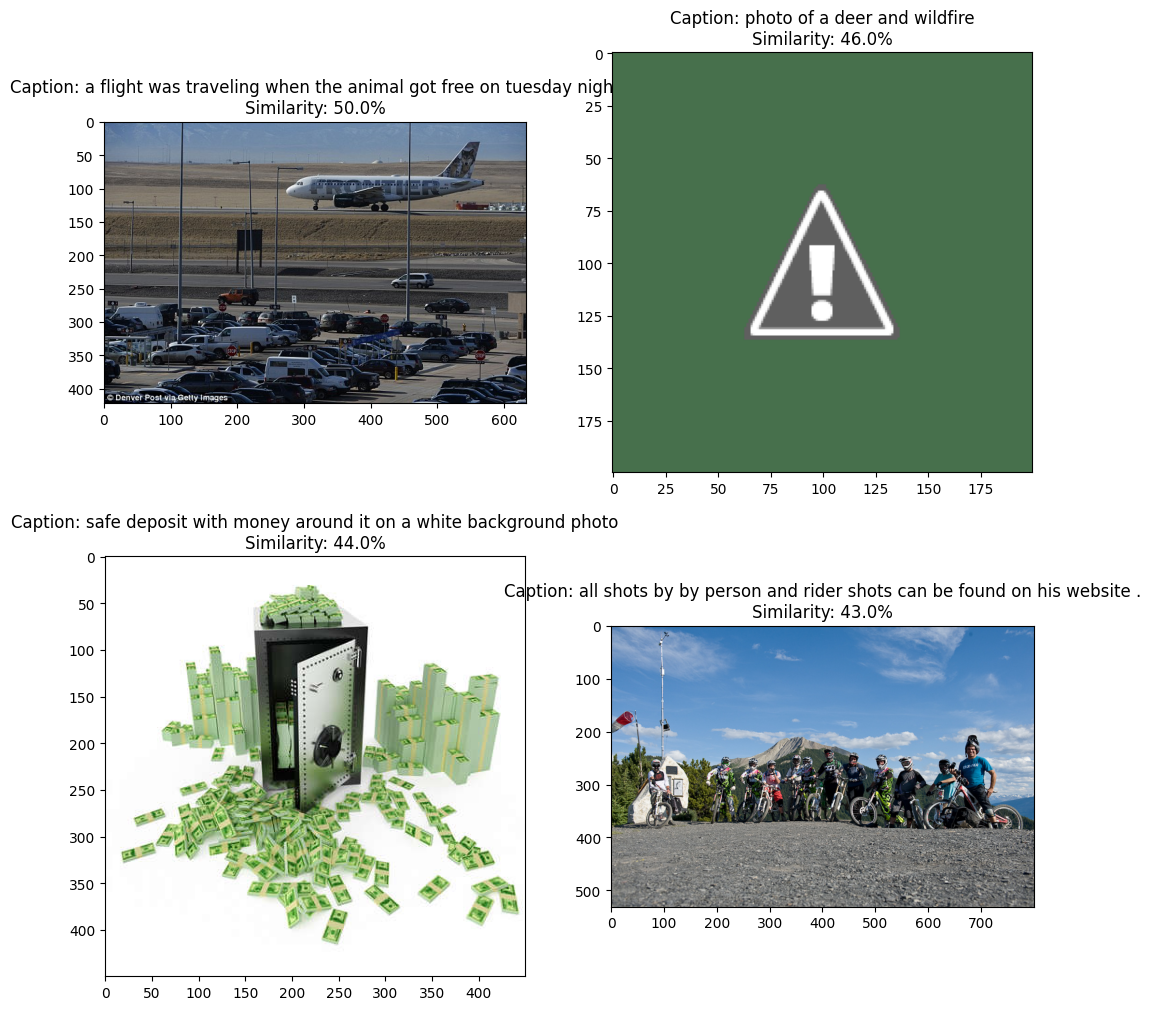

In [36]:
top_images = get_top_N_images(query_image, image_data_df, search_criterion="image")
plot_images_by_side(top_images)

# Approach n°2: Pinecone Client Library

#### Initializing the Index

Now we need a place to store these embeddings and enable a efficient vector search through them all. To do that we use Pinecone, we can get a [free API key](https://app.pinecone.io/) and enter it below where we will initialize our connection to Pinecone and create a new index.

In [ ]:
!pip install -qU langchain-pinecone pinecone-notebooks

In [42]:
import os
from pinecone import Pinecone
from dotenv import load_dotenv, find_dotenv

_ = load_dotenv(find_dotenv())
api_key = os.environ.get('PINECONE_API_KEY') or 'PINECONE_API_KEY'

# configure client
pc = Pinecone(api_key=api_key)

Now we setup our index specification, this allows us to define the cloud provider and region where we want to deploy our index. You can find a list of all [available providers and regions here](https://docs.pinecone.io/docs/projects).

In [44]:
from pinecone import ServerlessSpec

cloud = os.environ.get('PINECONE_CLOUD') or 'aws'
region = os.environ.get('PINECONE_REGION') or 'us-east-1'

spec = ServerlessSpec(cloud=cloud, region=region)

Create the index:

In [45]:
my_index_name = "clip-image-search"

In [46]:
import time

vector_dim = image_data_df.img_embeddings[0].shape[1]

# check if index already exists (it shouldn't if this is first time)
if my_index_name not in pc.list_indexes().names():
    # if does not exist, create index
    pc.create_index(
        my_index_name,
        dimension=vector_dim,
        metric='cosine',
        spec=spec
    )
    # wait for index to be initialized
    while not pc.describe_index(my_index_name).status['ready']:
        time.sleep(1)

# connect to index
my_index = pc.Index(my_index_name)
# view index stats
my_index.describe_index_stats()

{'dimension': 512,
 'index_fullness': 0.0,
 'namespaces': {},
 'total_vector_count': 0}

#### Prepare Vector

In [48]:
image_data_df["vector_id"] = image_data_df.index
image_data_df["vector_id"] = image_data_df["vector_id"].apply(str)

# Get all the metadata
final_metadata = []

for index in range(len(image_data_df)):
  final_metadata.append({
      'ID':  index,
      'caption': image_data_df.iloc[index].caption, 
      'image': image_data_df.iloc[index].image_url
  })

image_IDs = image_data_df.vector_id.tolist()
image_embeddings = [arr.flatten().tolist() for arr in image_data_df.img_embeddings.tolist()] 

# Create the single list of dictionary format to insert 
data_to_upsert = list(zip(image_IDs, image_embeddings, final_metadata))

# Upload the final data
my_index.upsert(vectors = data_to_upsert)

# Check index size for each namespace
my_index.describe_index_stats()

/var/folders/p8/n90ktjvn0mz196zbqfk664tm0000gn/T/ipykernel_67203/1372204412.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  image_data_df["vector_id"] = image_data_df.index
/var/folders/p8/n90ktjvn0mz196zbqfk664tm0000gn/T/ipykernel_67203/1372204412.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  image_data_df["vector_id"] = image_data_df["vector_id"].apply(str)


{'dimension': 512,
 'index_fullness': 0.0,
 'namespaces': {},
 'total_vector_count': 0}

### Text to image

In [49]:
text_query = image_data_df.iloc[10].caption
text_query

'all shots by by person and rider shots can be found on his website .'

In [50]:
# Get the caption embedding
query_embedding = get_single_text_embedding(text_query).tolist()

In [51]:
# Run the query
my_index.query(vector=query_embedding, top_k=4, include_metadata=True)

{'matches': [{'id': '19',
              'metadata': {'ID': 10.0,
                           'caption': 'all shots by by person and rider shots '
                                      'can be found on his website .',
                           'image': 'https://ep1.pinkbike.org/p4pb6973204/p4pb6973204.jpg'},
              'score': 0.272078335,
              'values': []},
             {'id': '7',
              'metadata': {'ID': 5.0,
                           'caption': 'traditional ornamental floral paisley '
                                      'bandanna .',
                           'image': 'https://thumb1.shutterstock.com/display_pic_with_logo/701386/201063638/stock-photo-traditional-ornamental-floral-paisley-bandanna-you-can-use-this-pattern-in-the-design-of-carpet-201063638.jpg'},
              'score': 0.218308657,
              'values': []},
             {'id': '3',
              'metadata': {'ID': 2.0,
                           'caption': 'interior design of modern living

### Image to image

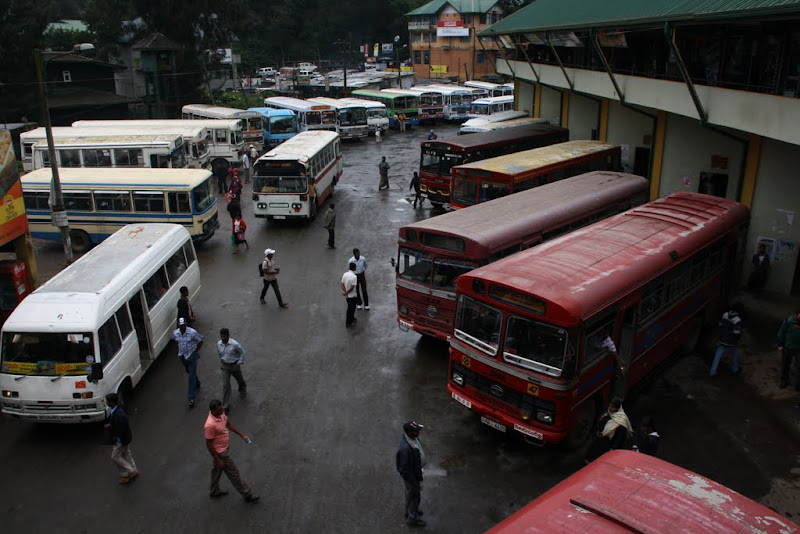

In [53]:
image_query = image_data_df.iloc[0].image
image_query

In [54]:
# Get the text embedding
query_embedding = get_single_image_embedding(image_query).tolist()

In [55]:
# Run the query
my_index.query(vector=query_embedding, top_k=4, include_metadata=True)

{'matches': [{'id': '0',
              'metadata': {'ID': 0.0,
                           'caption': 'a very typical bus station',
                           'image': 'http://lh6.ggpht.com/-IvRtNLNcG8o/TpFyrudaT6I/AAAAAAAAM6o/_11MuAAKalQ/IMG_3422.JPG?imgmax=800'},
              'score': 0.99999994,
              'values': []},
             {'id': '10',
              'metadata': {'ID': 7.0,
                           'caption': 'a flight was traveling when the animal '
                                      'got free on tuesday night',
                           'image': 'http://i.dailymail.co.uk/i/pix/2016/08/10/15/371349E500000578-0-image-a-15_1470837871650.jpg'},
              'score': 0.496373713,
              'values': []},
             {'id': '20',
              'metadata': {'ID': 11.0,
                           'caption': 'photo of a deer and wildfire',
                           'image': 'http://2.bp.blogspot.com/-cZpqM2kr2uc/U6v-pnIxM9I/AAAAAAAAaek/OFq7OBbqkv4/s1600/photo-of-a

#### Delete your index

Once finished with the index we can delete it to save resources.

In [ ]:
pc.delete_index(my_index_name)